# Fase 2 — Otimização via Algoritmo Genético + Interpretação com LLM
## Câncer de mama: Regressão Linear, Regressão Logística e Random Forest

Este notebook usa as funções de `src/ga_utils.py` (Algoritmo Genético) e `src/llm_utils.py` (integração com o Claude) para:

1. Otimizar os hiperparâmetros dos 3 modelos já treinados em `01_analise_e_modelagem.ipynb`.
2. Rodar 3 experimentos com configurações diferentes do GA (um por algoritmo).
3. Comparar cada modelo original com sua versão otimizada, no mesmo holdout de teste.
4. Usar a API da Anthropic (Claude) para gerar explicações em linguagem natural dos diagnósticos.

O loop de gerações do GA aparece direto nas células abaixo (um bloco por algoritmo) — dá pra acompanhar geração por geração o que está acontecendo, sem precisar pular pra outro arquivo.

## O que é um Algoritmo Genético (GA)?

*Por que usar uma "busca evolutiva" em vez de testar hiperparâmetros manualmente?*

Um Algoritmo Genético é uma técnica de otimização inspirada na seleção natural. Em vez de testar hiperparâmetros um por um (grid search) ou aleatoriamente (random search), ele mantém uma **população** de soluções candidatas e as faz "evoluir":

- **Indivíduo**: um dict com uma configuração completa de hiperparâmetros de um modelo.
- **Gene**: cada hiperparâmetro individual (uma chave do dict).
- **Fitness**: quão boa é aquela configuração — `0.5·recall + 0.3·F1 + 0.2·accuracy`, medidos por validação cruzada (5-fold).
- **Seleção**: as configurações com melhor fitness têm mais chance de "reproduzir".
- **Crossover**: duas configurações "pais" combinam seus genes para gerar "filhos".
- **Mutação**: pequenas alterações aleatórias, para explorar configurações novas.
- **Elitismo**: as melhores configurações da geração atual sempre sobrevivem para a próxima.

*Por que recall pesa mais na fitness?* Em diagnóstico de câncer, classificar um tumor **maligno como benigno** (falso negativo) é o erro mais grave clinicamente.

*Por que seleção por torneio?* É simples de implementar e funciona bem mesmo quando os fitness estão próximos entre si — sorteia `k` indivíduos, o melhor deles vira pai.

*Por que crossover uniforme?* Os hiperparâmetros não têm uma ordem natural entre si, então decidir gene a gene (independentemente) de qual pai herdar faz mais sentido do que cortar o dict num ponto fixo.

In [1]:
import sys
import json
import random
from pathlib import Path

SRC_DIR = Path.cwd().parent / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import ga_utils
import llm_utils

X_train, X_test, y_train, y_test, feature_names, scaler = ga_utils.carregar_dados()
print(f"Treino: {X_train.shape} | Teste: {X_test.shape}")

RESULTADOS_DIR = Path("..") / "experiments" / "results"
RESULTADOS_DIR.mkdir(parents=True, exist_ok=True)

Treino: (455, 30) | Teste: (114, 30)


In [2]:
def do_GA(populacao_inicial, geracoes, mutacao, fitness_func, mutar_func):
    historico = []
    populacao = populacao_inicial

    for geracao in range(geracoes):
        fitnesses = [fitness_func(ind, X_train, y_train, X_test, y_test) for ind in populacao]
        historico.append({"geracao": geracao, "melhor": max(fitnesses), "media": float(np.mean(fitnesses))})
        print(f"Geração {geracao}: melhor={max(fitnesses):.4f}  média={np.mean(fitnesses):.4f}")

        ranking = sorted(range(len(populacao)), key=lambda i: fitnesses[i], reverse=True)
        nova_populacao = [dict(populacao[i]) for i in ranking[:2]]
        while len(nova_populacao) < len(populacao):
            pai1 = ga_utils.selecao_torneio(populacao, fitnesses)
            pai2 = ga_utils.selecao_torneio(populacao, fitnesses)
            filho1, filho2 = ga_utils.crossover(pai1, pai2)
            nova_populacao.append(mutar_func(filho1, mutacao))
            if len(nova_populacao) < len(populacao):
                nova_populacao.append(mutar_func(filho2, mutacao))
        populacao = nova_populacao

    return populacao, historico, fitnesses

## Baseline (Fase 1) — modelos originais

Métricas obtidas em `01_analise_e_modelagem.ipynb`, no mesmo holdout de teste (20%, `random_state=42`):

| Modelo | Accuracy | Precision | Recall | F1 |
|---|---|---|---|---|
| Regressão Linear (limiar 0,5) | 0.9649 | 1.0000 | 0.9048 | 0.9500 |
| Regressão Logística | 0.9649 | 0.9750 | 0.9286 | 0.9512 |
| Random Forest | 0.9737 | 1.0000 | 0.9286 | 0.9630 |

Vamos rodar o GA para tentar melhorar cada um desses três — um experimento por algoritmo, cada um com uma configuração diferente do GA.

## Experimento 1 — GA na Regressão Linear

*Por que o limiar (threshold) entra como gene?* `LinearRegression` não tem hiperparâmetro de regularização como Ridge/Lasso — a única forma de melhorar a classificação sem trocar de modelo é ajustar o limiar que converte a predição contínua em classe 0/1 (hoje fixo em 0,5 no notebook 01). Junto com `fit_intercept` e `positive`, esse é o espaço de busca do GA aqui.

**Configuração deste experimento**: em vez de uma única configuração, rodamos várias combinações de população/gerações/mutação de uma vez (lista `CONFIGS_1`, editável — adicione ou troque entradas para testar outros valores).

- O CSV (`fitness_history_regressao_linear.csv`) passa a registrar o histórico geração-a-geração de **todas** as configurações, com colunas `experimento`/`pop`/`geracoes`/`mutacao` identificando de qual configuração cada linha veio.
- O JSON (`best_hyperparams_regressao_linear.json`) guarda só o melhor indivíduo entre **todas** as configurações (maior fitness), junto com a configuração que o gerou.
- Depois do treino plotamos um gráfico de convergência por configuração, e mais abaixo comparamos o resultado (no holdout de teste) de cada configuração.</cell_type>



--- Experimento 'Otimizado RL Experimento 1' (pop=10, geracoes=15, mutacao=0.1) ---
Geração 0: melhor=0.9722  média=0.7466
Geração 1: melhor=0.9722  média=0.9574


Geração 2: melhor=0.9722  média=0.9343


Geração 3: melhor=0.9722  média=0.9363
Geração 4: melhor=0.9722  média=0.9323
Geração 5: melhor=0.9722  média=0.9339


Geração 6: melhor=0.9774  média=0.9728


Geração 7: melhor=0.9774  média=0.9707
Geração 8: melhor=0.9774  média=0.9390
Geração 9: melhor=0.9774  média=0.9727


...

Geração 22: melhor=0.9774  média=0.9677


Geração 23: melhor=0.9774  média=0.9271
Geração 24: melhor=0.9774  média=0.9196


Geração 25: melhor=0.9774  média=0.9211
Geração 26: melhor=0.9774  média=0.9519


Geração 27: melhor=0.9774  média=0.8951
Geração 28: melhor=0.9774  média=0.9202


Geração 29: melhor=0.9774  média=0.9368
Melhores hiperparâmetros encontrados (Otimizado RL Experimento 4): {'fit_intercept': True, 'positive': True, 'threshold': 0.41476548674757086}  (fitness=0.9774)

=== Melhor de todos os experimentos: 'Otimizado RL Experimento 1' (fitness=0.9774) -> {'fit_intercept': True, 'positive': True, 'threshold': 0.37725191533108343} ===


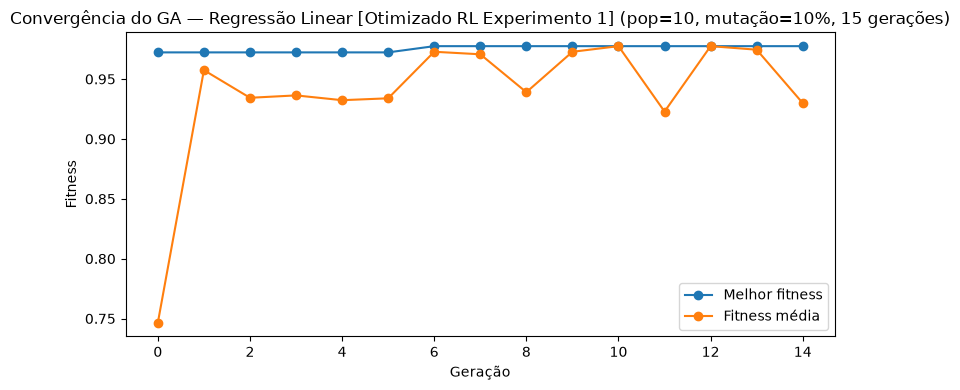

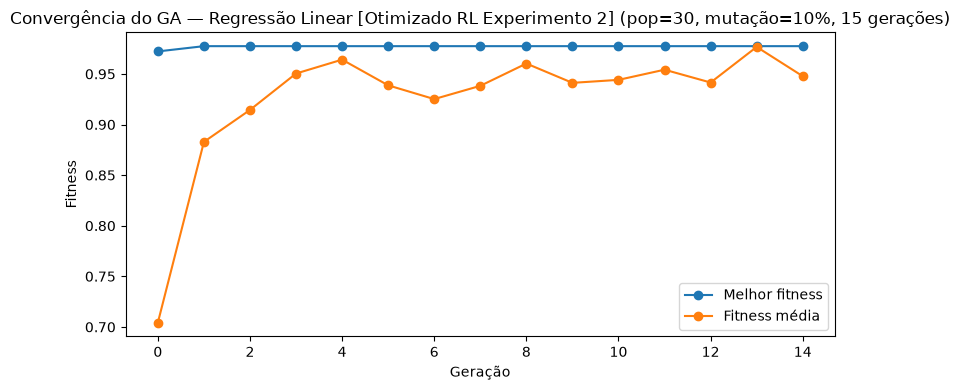

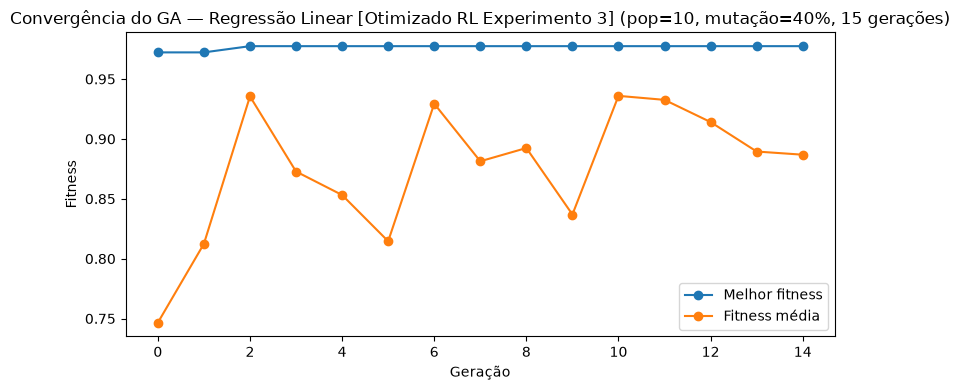

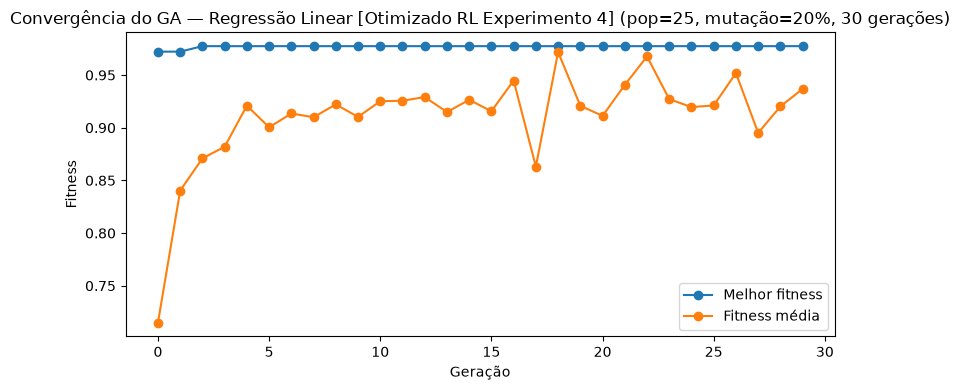

In [3]:
CONFIGS_1 = [
    {"nome": "Otimizado RL Experimento 1", "pop": 10, "geracoes": 15, "mutacao": 0.1},
    {"nome": "Otimizado RL Experimento 2", "pop": 30, "geracoes": 15, "mutacao": 0.1},
    {"nome": "Otimizado RL Experimento 3", "pop": 10, "geracoes": 15, "mutacao": 0.4},
    {"nome": "Otimizado RL Experimento 4", "pop": 25, "geracoes": 30, "mutacao": 0.2},
]

resultados_linear = {}
linhas_historico_linear = []
melhor_global_linear = None

for cfg in CONFIGS_1:
    random.seed(42)
    populacao_inicial = [ga_utils.criar_individuo_linear() for _ in range(cfg["pop"])]

    print(f"\n--- Experimento '{cfg['nome']}' (pop={cfg['pop']}, geracoes={cfg['geracoes']}, mutacao={cfg['mutacao']}) ---")
    populacao, historico, fitnesses = do_GA(
        populacao_inicial, cfg["geracoes"], cfg["mutacao"],
        ga_utils.fitness_linear, ga_utils.mutar_linear,
    )

    melhor_idx = int(np.argmax(fitnesses))
    melhor_individuo = populacao[melhor_idx]
    melhor_fitness = fitnesses[melhor_idx]

    for h in historico:
        linhas_historico_linear.append({
            **h,
            "experimento": cfg["nome"],
            "pop": cfg["pop"],
            "geracoes": cfg["geracoes"],
            "mutacao": cfg["mutacao"],
        })

    resultados_linear[cfg["nome"]] = {
        "config": cfg,
        "melhor_individuo": melhor_individuo,
        "melhor_fitness": melhor_fitness,
    }

    if melhor_global_linear is None or melhor_fitness > melhor_global_linear["melhor_fitness"]:
        melhor_global_linear = {
            "experimento": cfg["nome"],
            "pop": cfg["pop"],
            "geracoes": cfg["geracoes"],
            "mutacao": cfg["mutacao"],
            "melhor_individuo": melhor_individuo,
            "melhor_fitness": melhor_fitness,
        }

    print(f"Melhores hiperparâmetros encontrados ({cfg['nome']}): {melhor_individuo}  (fitness={melhor_fitness:.4f})")

melhor_linear = melhor_global_linear["melhor_individuo"]
print(f"\n=== Melhor de todos os experimentos: '{melhor_global_linear['experimento']}' "
      f"(fitness={melhor_global_linear['melhor_fitness']:.4f}) -> {melhor_linear} ===")

pd.DataFrame(linhas_historico_linear).to_csv(RESULTADOS_DIR / "fitness_history_regressao_linear.csv", index=False)
with open(RESULTADOS_DIR / "best_hyperparams_regressao_linear.json", "w") as f:
    json.dump({"algoritmo": "regressao_linear", **melhor_global_linear}, f, indent=2, default=str)

for cfg in CONFIGS_1:
    hist_cfg = [h for h in linhas_historico_linear if h["experimento"] == cfg["nome"]]
    plt.figure(figsize=(8, 4))
    plt.plot([h["geracao"] for h in hist_cfg], [h["melhor"] for h in hist_cfg], label="Melhor fitness", marker="o")
    plt.plot([h["geracao"] for h in hist_cfg], [h["media"] for h in hist_cfg], label="Fitness média", marker="o")
    plt.xlabel("Geração"); plt.ylabel("Fitness")
    plt.title(f"Convergência do GA — Regressão Linear [{cfg['nome']}] "
              f"(pop={cfg['pop']}, mutação={int(cfg['mutacao'] * 100)}%, {cfg['geracoes']} gerações)")
    plt.legend(); plt.tight_layout(); plt.show()

In [4]:
modelo_linear_original = ga_utils.construir_linear(ga_utils.LINEAR_BASELINE)
modelo_linear_original.fit(X_train, y_train)
y_pred_original = ga_utils.prever_linear(modelo_linear_original, X_test, ga_utils.LINEAR_BASELINE)
metricas_linear_original = ga_utils.calcular_metricas(y_test, y_pred_original)

linhas_comparacao_linear = [
    {"experimento": "Original (baseline)", "pop": None, "geracoes": None, "mutacao": None, **metricas_linear_original}
]

for nome, res in resultados_linear.items():
    modelo = ga_utils.construir_linear(res["melhor_individuo"])
    modelo.fit(X_train, y_train)
    y_pred = ga_utils.prever_linear(modelo, X_test, res["melhor_individuo"])
    metricas = ga_utils.calcular_metricas(y_test, y_pred)

    cfg = res["config"]
    linhas_comparacao_linear.append({
        "experimento": nome,
        "pop": cfg["pop"],
        "geracoes": cfg["geracoes"],
        "mutacao": cfg["mutacao"],
        **metricas,
    })

    if nome == melhor_global_linear["experimento"]:
        modelo_linear_otimizado = modelo
        metricas_linear_otimizado = metricas

comparacao_linear = pd.DataFrame(linhas_comparacao_linear)
comparacao_linear.to_csv(RESULTADOS_DIR / "comparison_table_regressao_linear.csv", index=False)
comparacao_linear

,experimento,pop,geracoes,mutacao,accuracy,precision,recall,f1
0,Original (baseline),NaN,NaN,NaN,0.964912,1.00000,0.904762,0.95000
1,Otimizado RL Experimento 1,10.0,15.0,0.1,0.982456,0.97619,0.976190,0.97619
2,Otimizado RL Experimento 2,30.0,15.0,0.1,0.982456,0.97619,0.976190,0.97619
3,Otimizado RL Experimento 3,10.0,15.0,0.4,0.982456,0.97619,0.976190,0.97619
4,Otimizado RL Experimento 4,25.0,30.0,0.2,0.982456,0.97619,0.976190,0.97619


## Experimento 2 — GA na Regressão Logística

*O que o GA está ajustando aqui?* `C` (inverso da força de regularização), `penalty` (L1 tende a zerar coeficientes menos relevantes, L2 só os encolhe) e `class_weight` (se as classes têm peso igual ou compensam o leve desbalanceamento do dataset).

**Configuração deste experimento**: assim como no Experimento 1, rodamos várias combinações de população/gerações/mutação de uma vez (lista `CONFIGS_2`, editável).

- O CSV (`fitness_history_regressao_logistica.csv`) registra o histórico geração-a-geração de **todas** as configurações, com colunas `experimento`/`pop`/`geracoes`/`mutacao`.
- O JSON (`best_hyperparams_regressao_logistica.json`) guarda só o melhor indivíduo entre **todas** as configurações.
- Depois do treino plotamos um gráfico de convergência por configuração, e mais abaixo comparamos o resultado (no holdout de teste) de cada configuração.</cell_type>



--- Experimento 'Otimizado LOG Experimento 1' (pop=20, geracoes=15, mutacao=0.1) ---
Geração 0: melhor=0.9601  média=0.9522


Geração 1: melhor=0.9654  média=0.9554
Geração 2: melhor=0.9774  média=0.9619


Geração 3: melhor=0.9774  média=0.9648
Geração 4: melhor=0.9774  média=0.9738


Geração 5: melhor=0.9774  média=0.9736
Geração 6: melhor=0.9774  média=0.9774


Geração 7: melhor=0.9774  média=0.9760


...

Geração 22: melhor=0.9774  média=0.9721


Geração 23: melhor=0.9774  média=0.9724
Geração 24: melhor=0.9774  média=0.9714


Geração 25: melhor=0.9774  média=0.9743
Geração 26: melhor=0.9774  média=0.9713


Geração 27: melhor=0.9774  média=0.9749
Geração 28: melhor=0.9774  média=0.9713


Geração 29: melhor=0.9774  média=0.9731
Melhores hiperparâmetros encontrados (Otimizado LOG Experimento 4): {'C': 0.3275089680230181, 'penalty': 'l2', 'class_weight': 'balanced'}  (fitness=0.9774)

=== Melhor de todos os experimentos: 'Otimizado LOG Experimento 2' (fitness=0.9947) -> {'C': 0.03673046880282847, 'penalty': 'l1', 'class_weight': 'balanced'} ===


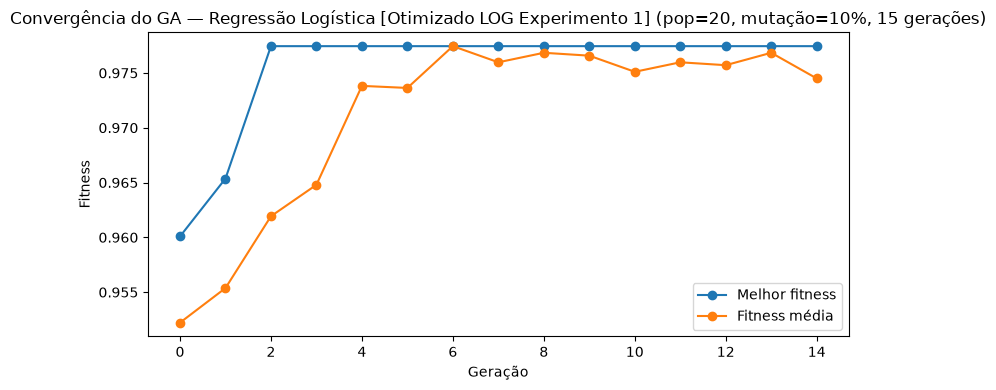

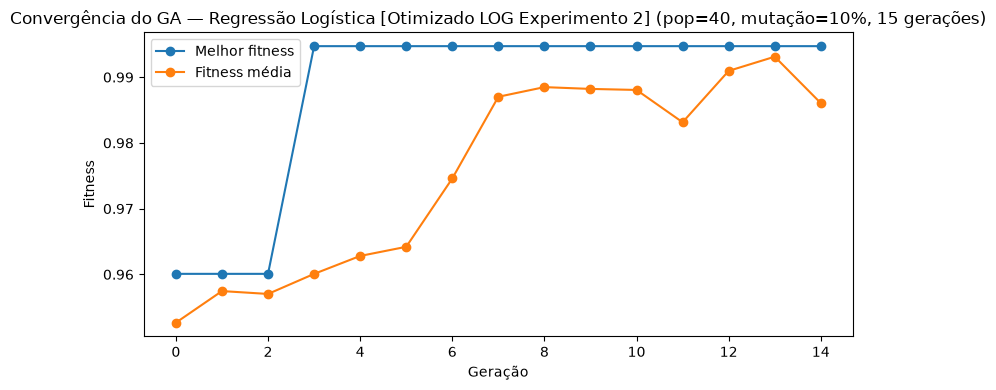

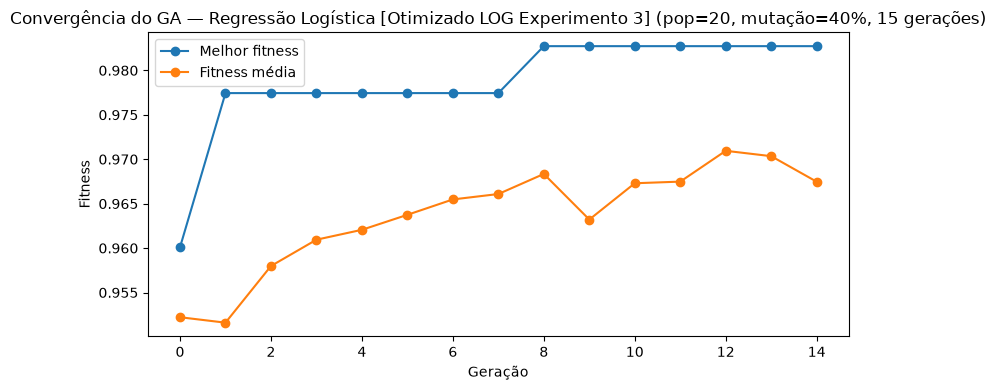

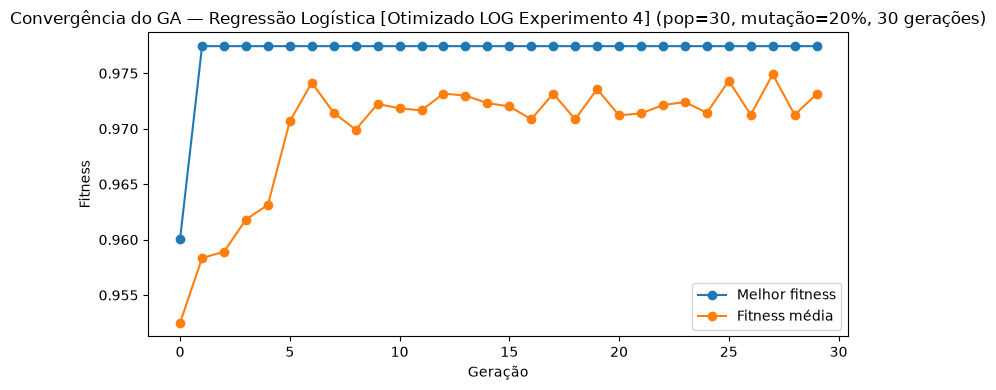

In [5]:
CONFIGS_2 = [
    {"nome": "Otimizado LOG Experimento 1", "pop": 20, "geracoes": 15, "mutacao": 0.1},
    {"nome": "Otimizado LOG Experimento 2", "pop": 40, "geracoes": 15, "mutacao": 0.1},
    {"nome": "Otimizado LOG Experimento 3", "pop": 20, "geracoes": 15, "mutacao": 0.4},
    {"nome": "Otimizado LOG Experimento 4", "pop": 30, "geracoes": 30, "mutacao": 0.2},
]

resultados_log = {}
linhas_historico_log = []
melhor_global_log = None

for cfg in CONFIGS_2:
    random.seed(42)
    populacao_inicial = [ga_utils.criar_individuo_log() for _ in range(cfg["pop"])]

    print(f"\n--- Experimento '{cfg['nome']}' (pop={cfg['pop']}, geracoes={cfg['geracoes']}, mutacao={cfg['mutacao']}) ---")
    populacao, historico, fitnesses = do_GA(
        populacao_inicial, cfg["geracoes"], cfg["mutacao"],
        ga_utils.fitness_log, ga_utils.mutar_log,
    )

    melhor_idx = int(np.argmax(fitnesses))
    melhor_individuo = populacao[melhor_idx]
    melhor_fitness = fitnesses[melhor_idx]

    for h in historico:
        linhas_historico_log.append({
            **h,
            "experimento": cfg["nome"],
            "pop": cfg["pop"],
            "geracoes": cfg["geracoes"],
            "mutacao": cfg["mutacao"],
        })

    resultados_log[cfg["nome"]] = {
        "config": cfg,
        "melhor_individuo": melhor_individuo,
        "melhor_fitness": melhor_fitness,
    }

    if melhor_global_log is None or melhor_fitness > melhor_global_log["melhor_fitness"]:
        melhor_global_log = {
            "experimento": cfg["nome"],
            "pop": cfg["pop"],
            "geracoes": cfg["geracoes"],
            "mutacao": cfg["mutacao"],
            "melhor_individuo": melhor_individuo,
            "melhor_fitness": melhor_fitness,
        }

    print(f"Melhores hiperparâmetros encontrados ({cfg['nome']}): {melhor_individuo}  (fitness={melhor_fitness:.4f})")

melhor_log = melhor_global_log["melhor_individuo"]
print(f"\n=== Melhor de todos os experimentos: '{melhor_global_log['experimento']}' "
      f"(fitness={melhor_global_log['melhor_fitness']:.4f}) -> {melhor_log} ===")

pd.DataFrame(linhas_historico_log).to_csv(RESULTADOS_DIR / "fitness_history_regressao_logistica.csv", index=False)
with open(RESULTADOS_DIR / "best_hyperparams_regressao_logistica.json", "w") as f:
    json.dump({"algoritmo": "regressao_logistica", **melhor_global_log}, f, indent=2, default=str)

for cfg in CONFIGS_2:
    hist_cfg = [h for h in linhas_historico_log if h["experimento"] == cfg["nome"]]
    plt.figure(figsize=(8, 4))
    plt.plot([h["geracao"] for h in hist_cfg], [h["melhor"] for h in hist_cfg], label="Melhor fitness", marker="o")
    plt.plot([h["geracao"] for h in hist_cfg], [h["media"] for h in hist_cfg], label="Fitness média", marker="o")
    plt.xlabel("Geração"); plt.ylabel("Fitness")
    plt.title(f"Convergência do GA — Regressão Logística [{cfg['nome']}] "
              f"(pop={cfg['pop']}, mutação={int(cfg['mutacao'] * 100)}%, {cfg['geracoes']} gerações)")
    plt.legend(); plt.tight_layout(); plt.show()

In [6]:
modelo_log_original = ga_utils.construir_log(ga_utils.LOG_BASELINE)
modelo_log_original.fit(X_train, y_train)
y_pred_original = modelo_log_original.predict(X_test)
metricas_log_original = ga_utils.calcular_metricas(y_test, y_pred_original)

linhas_comparacao_log = [
    {"experimento": "Original (baseline)", "pop": None, "geracoes": None, "mutacao": None, **metricas_log_original}
]

for nome, res in resultados_log.items():
    modelo = ga_utils.construir_log(res["melhor_individuo"])
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    metricas = ga_utils.calcular_metricas(y_test, y_pred)

    cfg = res["config"]
    linhas_comparacao_log.append({
        "experimento": nome,
        "pop": cfg["pop"],
        "geracoes": cfg["geracoes"],
        "mutacao": cfg["mutacao"],
        **metricas,
    })

    if nome == melhor_global_log["experimento"]:
        modelo_log_otimizado = modelo
        metricas_log_otimizado = metricas

comparacao_log = pd.DataFrame(linhas_comparacao_log)
comparacao_log.to_csv(RESULTADOS_DIR / "comparison_table_regressao_logistica.csv", index=False)
comparacao_log

,experimento,pop,geracoes,mutacao,accuracy,precision,recall,f1
0,Original (baseline),NaN,NaN,NaN,0.973684,0.975610,0.952381,0.963855
1,Otimizado LOG Experimento 1,20.0,15.0,0.1,0.982456,0.976190,0.976190,0.976190
2,Otimizado LOG Experimento 2,40.0,15.0,0.1,0.991228,0.976744,1.000000,0.988235
3,Otimizado LOG Experimento 3,20.0,15.0,0.4,0.991228,1.000000,0.976190,0.987952
4,Otimizado LOG Experimento 4,30.0,30.0,0.2,0.982456,0.976190,0.976190,0.976190


## Experimento 3 — GA no Random Forest

*O que o GA está ajustando aqui?* `n_estimators` (nº de árvores), `max_depth` (profundidade máxima), `min_samples_split`/`min_samples_leaf` (o quão fácil é criar uma nova divisão), `max_features` (quantas features considerar em cada split) e `criterion` (gini vs. entropia).

**Configuração deste experimento**: assim como nos Experimentos 1 e 2, rodamos várias combinações de população/gerações/mutação de uma vez (lista `CONFIGS_3`, editável).

- O CSV (`fitness_history_random_forest.csv`) registra o histórico geração-a-geração de **todas** as configurações, com colunas `experimento`/`pop`/`geracoes`/`mutacao`.
- O JSON (`best_hyperparams_random_forest.json`) guarda só o melhor indivíduo entre **todas** as configurações.
- Depois do treino plotamos um gráfico de convergência por configuração, e mais abaixo comparamos o resultado (no holdout de teste) de cada configuração.</cell_type>



--- Experimento 'Otimizado RF Experimento 1' (pop=20, geracoes=20, mutacao=0.1) ---


Geração 0: melhor=0.9479  média=0.9273


Geração 1: melhor=0.9479  média=0.9313


Geração 2: melhor=0.9479  média=0.9353


Geração 3: melhor=0.9479  média=0.9400


...

Geração 30: melhor=0.9479  média=0.9421


Geração 31: melhor=0.9479  média=0.9407


Geração 32: melhor=0.9479  média=0.9399


Geração 33: melhor=0.9479  média=0.9417


Geração 34: melhor=0.9479  média=0.9432
Melhores hiperparâmetros encontrados (Otimizado RF Experimento 4): {'n_estimators': 200, 'max_depth': 5, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': None, 'criterion': 'entropy'}  (fitness=0.9479)

=== Melhor de todos os experimentos: 'Otimizado RF Experimento 1' (fitness=0.9479) -> {'n_estimators': 200, 'max_depth': 5, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': None, 'criterion': 'entropy'} ===


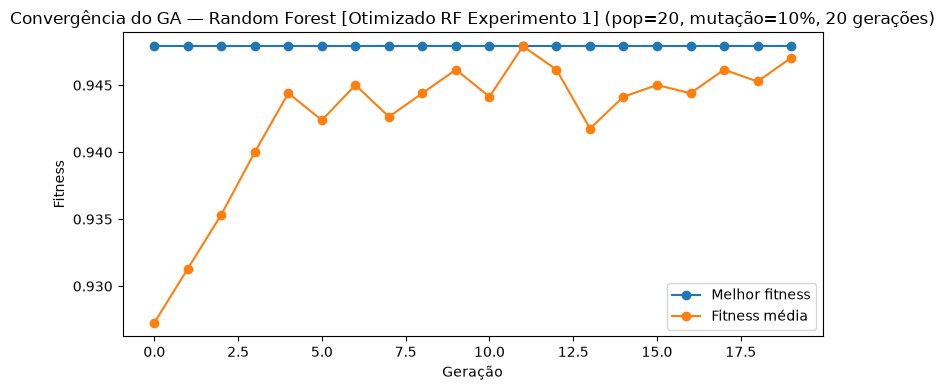

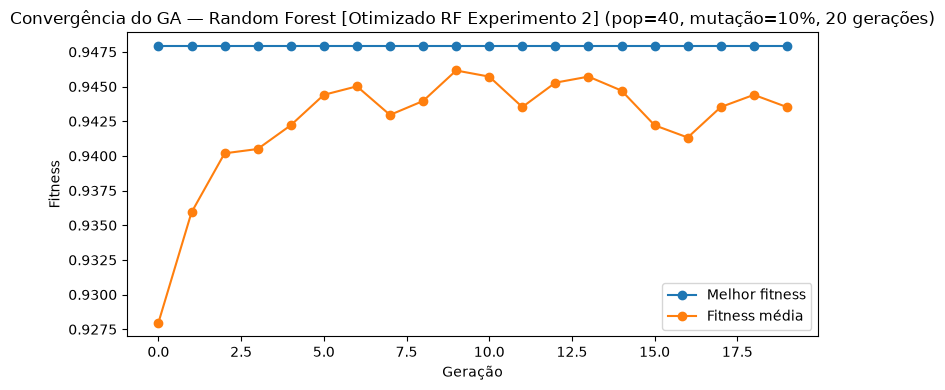

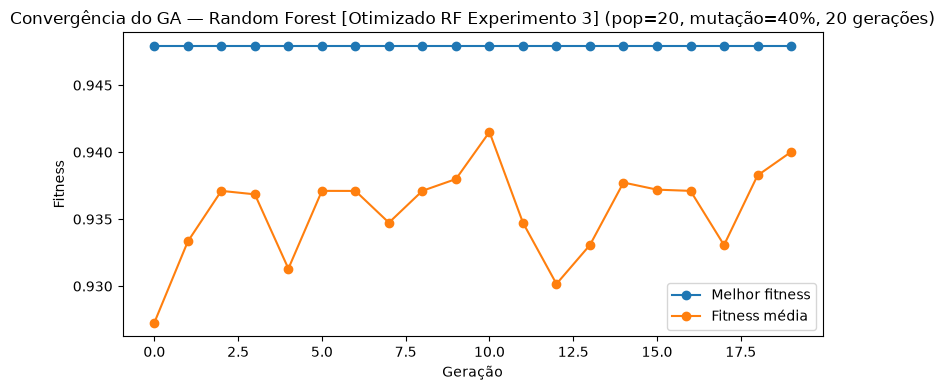

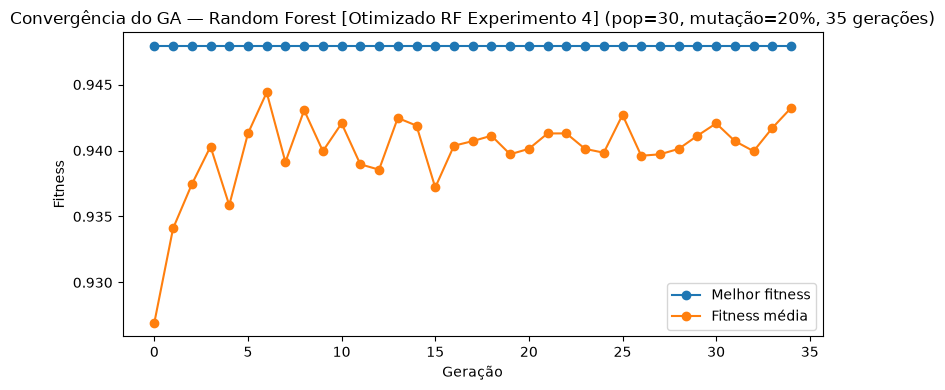

In [7]:
CONFIGS_3 = [
    {"nome": "Otimizado RF Experimento 1", "pop": 20, "geracoes": 20, "mutacao": 0.1},
    {"nome": "Otimizado RF Experimento 2", "pop": 40, "geracoes": 20, "mutacao": 0.1},
    {"nome": "Otimizado RF Experimento 3", "pop": 20, "geracoes": 20, "mutacao": 0.4},
    {"nome": "Otimizado RF Experimento 4", "pop": 30, "geracoes": 35, "mutacao": 0.2},
]

resultados_rf = {}
linhas_historico_rf = []
melhor_global_rf = None

for cfg in CONFIGS_3:
    random.seed(42)
    populacao_inicial = [ga_utils.criar_individuo_rf() for _ in range(cfg["pop"])]

    print(f"\n--- Experimento '{cfg['nome']}' (pop={cfg['pop']}, geracoes={cfg['geracoes']}, mutacao={cfg['mutacao']}) ---")
    populacao, historico, fitnesses = do_GA(
        populacao_inicial, cfg["geracoes"], cfg["mutacao"],
        ga_utils.fitness_rf, ga_utils.mutar_rf,
    )

    melhor_idx = int(np.argmax(fitnesses))
    melhor_individuo = populacao[melhor_idx]
    melhor_fitness = fitnesses[melhor_idx]

    for h in historico:
        linhas_historico_rf.append({
            **h,
            "experimento": cfg["nome"],
            "pop": cfg["pop"],
            "geracoes": cfg["geracoes"],
            "mutacao": cfg["mutacao"],
        })

    resultados_rf[cfg["nome"]] = {
        "config": cfg,
        "melhor_individuo": melhor_individuo,
        "melhor_fitness": melhor_fitness,
    }

    if melhor_global_rf is None or melhor_fitness > melhor_global_rf["melhor_fitness"]:
        melhor_global_rf = {
            "experimento": cfg["nome"],
            "pop": cfg["pop"],
            "geracoes": cfg["geracoes"],
            "mutacao": cfg["mutacao"],
            "melhor_individuo": melhor_individuo,
            "melhor_fitness": melhor_fitness,
        }

    print(f"Melhores hiperparâmetros encontrados ({cfg['nome']}): {melhor_individuo}  (fitness={melhor_fitness:.4f})")

melhor_rf = melhor_global_rf["melhor_individuo"]
print(f"\n=== Melhor de todos os experimentos: '{melhor_global_rf['experimento']}' "
      f"(fitness={melhor_global_rf['melhor_fitness']:.4f}) -> {melhor_rf} ===")

pd.DataFrame(linhas_historico_rf).to_csv(RESULTADOS_DIR / "fitness_history_random_forest.csv", index=False)
with open(RESULTADOS_DIR / "best_hyperparams_random_forest.json", "w") as f:
    json.dump({"algoritmo": "random_forest", **melhor_global_rf}, f, indent=2, default=str)

for cfg in CONFIGS_3:
    hist_cfg = [h for h in linhas_historico_rf if h["experimento"] == cfg["nome"]]
    plt.figure(figsize=(8, 4))
    plt.plot([h["geracao"] for h in hist_cfg], [h["melhor"] for h in hist_cfg], label="Melhor fitness", marker="o")
    plt.plot([h["geracao"] for h in hist_cfg], [h["media"] for h in hist_cfg], label="Fitness média", marker="o")
    plt.xlabel("Geração"); plt.ylabel("Fitness")
    plt.title(f"Convergência do GA — Random Forest [{cfg['nome']}] "
              f"(pop={cfg['pop']}, mutação={int(cfg['mutacao'] * 100)}%, {cfg['geracoes']} gerações)")
    plt.legend(); plt.tight_layout(); plt.show()

In [8]:
modelo_rf_original = ga_utils.construir_rf(ga_utils.RF_BASELINE)
modelo_rf_original.fit(X_train, y_train)
y_pred_original = modelo_rf_original.predict(X_test)
metricas_rf_original = ga_utils.calcular_metricas(y_test, y_pred_original)

linhas_comparacao_rf = [
    {"experimento": "Original (baseline)", "pop": None, "geracoes": None, "mutacao": None, **metricas_rf_original}
]

for nome, res in resultados_rf.items():
    modelo = ga_utils.construir_rf(res["melhor_individuo"])
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    metricas = ga_utils.calcular_metricas(y_test, y_pred)

    cfg = res["config"]
    linhas_comparacao_rf.append({
        "experimento": nome,
        "pop": cfg["pop"],
        "geracoes": cfg["geracoes"],
        "mutacao": cfg["mutacao"],
        **metricas,
    })

    if nome == melhor_global_rf["experimento"]:
        modelo_rf_otimizado = modelo
        metricas_rf_otimizado = metricas

comparacao_rf = pd.DataFrame(linhas_comparacao_rf)
comparacao_rf.to_csv(RESULTADOS_DIR / "comparison_table_random_forest.csv", index=False)
comparacao_rf

,experimento,pop,geracoes,mutacao,accuracy,precision,recall,f1
0,Original (baseline),NaN,NaN,NaN,0.973684,1.0,0.928571,0.962963
1,Otimizado RF Experimento 1,20.0,20.0,0.1,0.973684,1.0,0.928571,0.962963
2,Otimizado RF Experimento 2,40.0,20.0,0.1,0.973684,1.0,0.928571,0.962963
3,Otimizado RF Experimento 3,20.0,20.0,0.4,0.973684,1.0,0.928571,0.962963
4,Otimizado RF Experimento 4,30.0,35.0,0.2,0.973684,1.0,0.928571,0.962963


## Comparação final — os 3 algoritmos, original vs. otimizado

Tabela consolidada (também salva em `experiments/results/comparison_table.csv`).

In [9]:
linhas = [
    {"algoritmo": "regressao_linear", "versao": "Original", **metricas_linear_original},
    {"algoritmo": "regressao_linear", "versao": "Otimizado (GA)", **metricas_linear_otimizado},
    {"algoritmo": "regressao_logistica", "versao": "Original", **metricas_log_original},
    {"algoritmo": "regressao_logistica", "versao": "Otimizado (GA)", **metricas_log_otimizado},
    {"algoritmo": "random_forest", "versao": "Original", **metricas_rf_original},
    {"algoritmo": "random_forest", "versao": "Otimizado (GA)", **metricas_rf_otimizado},
]
comparacao_final = pd.DataFrame(linhas)
comparacao_final.to_csv(RESULTADOS_DIR / "comparison_table.csv", index=False)
comparacao_final

,algoritmo,versao,accuracy,precision,recall,f1
0,regressao_linear,Original,0.964912,1.000000,0.904762,0.950000
1,regressao_linear,Otimizado (GA),0.982456,0.976190,0.976190,0.976190
2,regressao_logistica,Original,0.973684,0.975610,0.952381,0.963855
3,regressao_logistica,Otimizado (GA),0.991228,0.976744,1.000000,0.988235
4,random_forest,Original,0.973684,1.000000,0.928571,0.962963
5,random_forest,Otimizado (GA),0.973684,1.000000,0.928571,0.962963


In [10]:
modelos_otimizados = {
    "regressao_linear": (modelo_linear_otimizado, melhor_linear, metricas_linear_otimizado),
    "regressao_logistica": (modelo_log_otimizado, melhor_log, metricas_log_otimizado),
    "random_forest": (modelo_rf_otimizado, melhor_rf, metricas_rf_otimizado),
}

melhor_algoritmo = max(modelos_otimizados, key=lambda nome: (modelos_otimizados[nome][2]["recall"], modelos_otimizados[nome][2]["f1"]))
print(f"Melhor modelo otimizado geral (maior recall, desempate por F1): {melhor_algoritmo}")

Melhor modelo otimizado geral (maior recall, desempate por F1): regressao_logistica


## O que é Prompt Engineering?

*Por que não simplesmente perguntar "explique esse resultado" pro Claude?*

Prompt engineering é estruturar deliberadamente a entrada (prompt) de uma LLM para obter respostas mais úteis e consistentes. O template em `src/llm_utils.py` (`montar_prompt`):

- **Define um papel** ("você é um assistente que ajuda profissionais de saúde...") — ancora o tom e o vocabulário da resposta.
- **Explicita os limites** ("NÃO substitui diagnóstico médico") — evita que a LLM soe mais confiante do que deveria.
- **Passa dados estruturados** (predição, confiança, features mais influentes, métricas do modelo) em vez de perguntar "o que você acha" — ancora a resposta em fatos concretos do modelo.
- **Pede um formato de saída específico** (3-5 frases, sem jargão) — facilita comparar respostas entre si e mantém a explicação curta o suficiente para uso clínico real.

In [11]:
modelo_final, hiperparametros_final, metricas_final = modelos_otimizados[melhor_algoritmo]

if melhor_algoritmo == "regressao_linear":
    y_pred_final = ga_utils.prever_linear(modelo_final, X_test, hiperparametros_final)
else:
    y_pred_final = modelo_final.predict(X_test)

y_test_arr = np.asarray(y_test)

idx_acerto = next(i for i in range(len(y_test_arr)) if y_pred_final[i] == y_test_arr[i])
idx_erro_candidatos = [i for i in range(len(y_test_arr)) if y_pred_final[i] != y_test_arr[i]]
idx_erro = idx_erro_candidatos[0] if idx_erro_candidatos else idx_acerto

if os.environ.get("ANTHROPIC_API_KEY"):
    chamar_llm = True
else:
    chamar_llm = False
    print(
        "ANTHROPIC_API_KEY não configurada — defina a variável de ambiente para "
        "chamar a API de verdade. As células abaixo vão montar e mostrar o prompt, "
        "mas sem chamar o Claude."
    )

ANTHROPIC_API_KEY não configurada — defina a variável de ambiente para chamar a API de verdade. As células abaixo vão montar e mostrar o prompt, mas sem chamar o Claude.


### Demonstração: interpretando um caso de acerto e um caso de erro do melhor modelo

Mostrar também um caso de **erro** é proposital: a explicação da LLM ajuda a auditar por que o modelo errou, não só a "vender" os acertos.

In [12]:
for rotulo, idx in [("Caso com acerto", idx_acerto), ("Caso com erro", idx_erro)]:
    print(f"\n=== {rotulo} (índice {idx}) ===")
    predicao_texto = "Maligno" if y_pred_final[idx] == 1 else "Benigno"

    if hasattr(modelo_final, "predict_proba"):
        probabilidade = modelo_final.predict_proba(X_test[idx : idx + 1])[0][y_pred_final[idx]]
    else:
        threshold = hiperparametros_final.get("threshold", 0.5)
        probabilidade = 0.5 + abs(modelo_final.predict(X_test[idx : idx + 1])[0] - threshold)

    features_importantes = llm_utils.obter_features_importantes(modelo_final, feature_names, X_test[idx])
    prompt = llm_utils.montar_prompt(
        predicao=predicao_texto,
        probabilidade=float(probabilidade),
        features_importantes=features_importantes,
        accuracy=metricas_final["accuracy"],
        recall=metricas_final["recall"],
        f1=metricas_final["f1"],
    )
    print(prompt)

    if chamar_llm:
        explicacao = llm_utils.gerar_explicacao(prompt)
        print("\n--- Explicação gerada pelo Claude ---")
        print(explicacao)


=== Caso com acerto (índice 0) ===
Você é um assistente que ajuda profissionais de saúde a interpretar resultados de um modelo de machine learning para triagem de câncer de mama. Este modelo é uma ferramenta de apoio à decisão, NÃO substitui diagnóstico médico.

O modelo classificou este caso como: BENIGNO (confiança: 88%)

As características que mais influenciaram essa classificação foram:
- radius_worst: -0.721 (importância: 1.248)
- concave points_worst: -0.388 (importância: 0.733)
- concave points_mean: -0.575 (importância: 0.493)

Desempenho geral do modelo: acurácia 99.1%, recall 100.0%, F1 0.99.

Escreva uma explicação curta (3 a 5 frases), em português, para a equipe médica, sem jargão de machine learning, dizendo por que o modelo chegou nessa classificação e reforçando que é uma triagem, não um diagnóstico definitivo.

=== Caso com erro (índice 92) ===
Você é um assistente que ajuda profissionais de saúde a interpretar resultados de um modelo de machine learning para triagem 

## Avaliação qualitativa das explicações da LLM

Não existe métrica automática confiável para "qualidade de uma explicação médica em texto livre". Adotamos uma avaliação manual com 3 critérios (nota 1 a 5):

| Critério | O que avalia |
|---|---|
| Clareza | Dá pra entender sem saber nada de ML? |
| Correção clínica | Os termos usados fazem sentido médico? |
| Utilidade acionável | Ajuda a equipe a decidir algo (priorizar, questionar, confirmar)? |

Preencher a tabela abaixo depois de rodar a célula anterior com `ANTHROPIC_API_KEY` configurada, avaliando as explicações geradas para os dois casos.

In [13]:
avaliacao_qualitativa = pd.DataFrame(
    columns=["caso", "clareza", "correcao_clinica", "utilidade_acionavel", "comentario"],
    data=[
        ["Caso com acerto", None, None, None, ""],
        ["Caso com erro", None, None, None, ""],
    ],
)
avaliacao_qualitativa

,caso,clareza,correcao_clinica,utilidade_acionavel,comentario
0,Caso com acerto,None,None,None,
1,Caso com erro,None,None,None,


## Conclusão

- Os 3 algoritmos do notebook 01 foram otimizados via Algoritmo Genético, cada um com um espaço de genes adequado ao seu tipo de hiperparâmetro.
- 3 experimentos, cada um com uma configuração diferente do GA (população/mutação/gerações), cobrindo os 3 algoritmos.
- A tabela de comparação final (`experiments/results/comparison_table.csv`) mostra o ganho (ou não) de cada modelo otimizado em relação ao seu baseline original.
- A integração com a LLM traduz predições individuais em explicações que uma equipe médica consegue interpretar sem conhecimento de ML, incluindo o caso de erro — que é onde a interpretabilidade mais importa.

Próximos passos possíveis (fora do escopo desta entrega): expandir o espaço de genes do GA, testar outros pesos na função de fitness, ou usar a LLM também para gerar relatórios agregados de vários casos.